# 08. Treinamento de Modelos - TimeSeriesSplit & Threshold Financeiro

## 🎯 Objetivo

Implementar **treinamento de modelos de ML** seguindo as **melhores práticas para detecção de fraude**:

1. **TimeSeriesSplit**: Validação cruzada temporal (em vez de CV aleatório)
2. **Balanceamento correto**: SMOTE/RUS **dentro dos folds** de treino
3. **Threshold financeiro**: Otimização baseada em **Matriz de Custo**
4. **Curva Precision-Recall**: Métrica mais adequada que ROC para classes desbalanceadas

## 📚 Melhores Práticas Implementadas

### ✅ Ponto 8 - Balanceamento de Classes
- **SMOTE aplicado dentro dos folds de CV** (nunca no dataset completo)
- Alternativa: `scale_pos_weight` (XGBoost/LightGBM)

### ✅ Ponto 9 - Validação Temporal
- **TimeSeriesSplit** em vez de StratifiedKFold
- Simula cenário real de produção (treino no passado, teste no futuro)

### ✅ Ponto 10 - Threshold Financeiro (CRÍTICO)
- **Matriz de Custo**:
  - FN (False Negative): Custo da fraude não detectada = Valor da transação
  - FP (False Positive): Custo de bloquear cliente legítimo = Custo fixo de fricção
- **Threshold ótimo**: Minimiza custo total (não usa 0.5 padrão)
- **Precision-Recall Curve**: Mais informativa que ROC

---

## 1. Setup - Importações e Configuração

### 📦 Bibliotecas Adicionais Necessárias

Para executar todas as funcionalidades deste notebook, instale:

```bash
pip install xgboost lightgbm shap
```

Ou usando conda:
```bash
conda install -c conda-forge xgboost lightgbm shap
```

In [3]:
# Teste rápido de importação das bibliotecas
try:
    import xgboost as xgb
    print(f"✅ XGBoost {xgb.__version__} instalado com sucesso!")
except ImportError as e:
    print(f"❌ XGBoost não encontrado: {e}")

try:
    import lightgbm as lgb
    print(f"✅ LightGBM {lgb.__version__} instalado com sucesso!")
except ImportError as e:
    print(f"❌ LightGBM não encontrado: {e}")

try:
    import shap
    print(f"✅ SHAP {shap.__version__} instalado com sucesso!")
except ImportError as e:
    print(f"❌ SHAP não encontrado: {e}")

print("\n🎉 Todas as bibliotecas estão prontas para uso!")

✅ XGBoost 3.1.3 instalado com sucesso!
✅ LightGBM 4.6.0 instalado com sucesso!
✅ SHAP 0.50.0 instalado com sucesso!

🎉 Todas as bibliotecas estão prontas para uso!


In [4]:
# Configurar path para importar módulos do projeto
import sys
from pathlib import Path

notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    sys.path.insert(0, str(notebook_dir.parent))

# Importar configurações do projeto
from source.config import PROJ_ROOT, get_data_path, get_model_path, get_figure_path, ensure_directories

# Garantir que os diretórios existam
ensure_directories()

print(f"✅ Projeto Root: {PROJ_ROOT}")
print(f"✅ Configurações carregadas de source/config.py")

2026-02-02 22:29:29.030 | INFO     | source.config:<module>:77 - [CONFIG] PROJ_ROOT: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering
2026-02-02 22:29:29.030 | INFO     | source.config:<module>:78 - [CONFIG] Python executando de: c:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\notebooks
✅ Projeto Root: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering
✅ Configurações carregadas de source/config.py


In [5]:
# Importações padrão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import json
import joblib
from typing import Dict, Tuple

# Scikit-Learn - Validação e Métricas
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    make_scorer
)

# Scikit-Learn - Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, 
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier

# XGBoost e LightGBM
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost não disponível. Instale com: pip install xgboost")

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("⚠️  LightGBM não disponível. Instale com: pip install lightgbm")

# SHAP para explicabilidade
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP não disponível. Instale com: pip install shap")

# Imbalanced-Learn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

# Configurações
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', None)

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Bibliotecas importadas com sucesso!")
if XGBOOST_AVAILABLE:
    print("✅ XGBoost disponível")
if LIGHTGBM_AVAILABLE:
    print("✅ LightGBM disponível")
if SHAP_AVAILABLE:
    print("✅ SHAP disponível para explicabilidade")


# Funções para KS e PSI
def calculate_ks(y_true, y_pred_proba):
    """
    Calcula a estatística KS (Kolmogorov-Smirnov).
    
    Args:
        y_true: Target real
        y_pred_proba: Probabilidades preditas
    
    Returns:
        KS statistic (float)
    """
    # Calcular FPR e TPR
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    
    # KS = max(TPR - FPR)
    ks = np.max(tpr - fpr)
    
    return ks


def calculate_psi(expected, actual, buckets=10):
    """
    Calcula o PSI (Population Stability Index).
    
    Args:
        expected: Distribuição esperada (probabilidades do treino)
        actual: Distribuição atual (probabilidades do teste/OOT)
        buckets: Número de bins para discretização
    
    Returns:
        PSI value (float)
    """
    # Criar bins baseados nos percentis da distribuição esperada
    breakpoints = np.percentile(expected, np.arange(0, 100, 100/buckets))
    breakpoints = np.unique(breakpoints)  # Remover duplicatas
    breakpoints = np.append(breakpoints, np.inf)
    breakpoints[0] = -np.inf
    
    # Calcular distribuições
    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    # Evitar divisão por zero e log de zero
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    
    # Calcular PSI
    psi = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    
    return psi


print("✅ Funções KS e PSI definidas!")

✅ Bibliotecas importadas com sucesso!
✅ XGBoost disponível
✅ LightGBM disponível
✅ SHAP disponível para explicabilidade
✅ Funções KS e PSI definidas!


## 2. Carregamento dos Dados Transformados

Carregamos os dados **já transformados** pelo Notebook 06.

In [6]:
print("="*80)
print("CARREGAMENTO DOS DADOS TRANSFORMADOS")
print("="*80)

# Carregar datasets
X_train = pd.read_csv(get_data_path('X_train.csv', 'processed'))
X_oot = pd.read_csv(get_data_path('X_oot.csv', 'processed'))
y_train = pd.read_csv(get_data_path('y_train.csv', 'processed')).squeeze()
y_oot = pd.read_csv(get_data_path('y_oot.csv', 'processed')).squeeze()

print(f"\n📊 Treino:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   Taxa de lavagem: {y_train.mean()*100:.2f}%")

print(f"\n📊 OOT:")
print(f"   X_oot: {X_oot.shape}")
print(f"   y_oot: {y_oot.shape}")
print(f"   Taxa de lavagem: {y_oot.mean()*100:.2f}%")

print(f"\n✅ Dados carregados com sucesso!")

CARREGAMENTO DOS DADOS TRANSFORMADOS

📊 Treino:
   X_train: (14375186, 59)
   y_train: (14375186,)
   Taxa de lavagem: 0.11%

📊 OOT:
   X_oot: (2395950, 59)
   y_oot: (2395950,)
   Taxa de lavagem: 0.23%

✅ Dados carregados com sucesso!


## 3. Configuração de Modelos

Definimos os modelos a serem treinados com hiperparâmetros ajustados para classes desbalanceadas.

In [7]:
# Distribuição de classes
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

print(f"📊 Distribuição de Classes:")
print(f"   Negativos (Normal): {negative_count:,}")
print(f"   Positivos (Lavagem): {positive_count:,}")
print(f"   Razão Desbalanceamento: {negative_count/positive_count:.2f}:1")
print(f"\n💡 Usando RUS (Random Under Sampling) para balanceamento")

# Dicionário de modelos expandido com mais ensemble algorithms
models = {
    'Logistic Regression': LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver='saga',
        n_jobs=-1
    ),
    
    'Random Forest': RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        n_jobs=-1
    ),
    
    'Extra Trees': ExtraTreesClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        max_depth=10,
        min_samples_split=50,
        min_samples_leaf=20,
        n_jobs=-1
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8
    ),
    
    'AdaBoost': AdaBoostClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        learning_rate=0.1
    ),
    
    'KNN': KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        n_jobs=-1
    )
}

# Adicionar XGBoost se disponível
if XGBOOST_AVAILABLE:
    models['XGBoost'] = xgb.XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    )

# Adicionar LightGBM se disponível
if LIGHTGBM_AVAILABLE:
    models['LightGBM'] = lgb.LGBMClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbose=-1
    )

print(f"\n✅ {len(models)} modelos configurados:")
for model_name in models.keys():
    print(f"   - {model_name}")

📊 Distribuição de Classes:
   Negativos (Normal): 14,359,659
   Positivos (Lavagem): 15,527
   Razão Desbalanceamento: 924.82:1

💡 Usando RUS (Random Under Sampling) para balanceamento

✅ 8 modelos configurados:
   - Logistic Regression
   - Random Forest
   - Extra Trees
   - Gradient Boosting
   - AdaBoost
   - KNN
   - XGBoost
   - LightGBM


## 4. Validação Temporal com TimeSeriesSplit

⚠️ **CRÍTICO**: Usamos TimeSeriesSplit em vez de KFold para respeitar a ordem temporal.

In [8]:
# Configurar TimeSeriesSplit
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print("="*80)
print("CONFIGURAÇÃO DE VALIDAÇÃO TEMPORAL")
print("="*80)

print(f"\n📅 TimeSeriesSplit com {n_splits} splits")
print(f"\n✓ Cada fold:")

# Visualizar splits
for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X_train), 1):
    print(f"\n  Fold {fold_idx}:")
    print(f"    Treino: {len(train_idx):,} samples")
    print(f"    Validação: {len(val_idx):,} samples")
    print(f"    Proporção: {len(train_idx)/len(X_train)*100:.1f}% treino / {len(val_idx)/len(X_train)*100:.1f}% val")

CONFIGURAÇÃO DE VALIDAÇÃO TEMPORAL

📅 TimeSeriesSplit com 5 splits

✓ Cada fold:

  Fold 1:
    Treino: 2,395,866 samples
    Validação: 2,395,864 samples
    Proporção: 16.7% treino / 16.7% val

  Fold 2:
    Treino: 4,791,730 samples
    Validação: 2,395,864 samples
    Proporção: 33.3% treino / 16.7% val

  Fold 3:
    Treino: 7,187,594 samples
    Validação: 2,395,864 samples
    Proporção: 50.0% treino / 16.7% val

  Fold 4:
    Treino: 9,583,458 samples
    Validação: 2,395,864 samples
    Proporção: 66.7% treino / 16.7% val

  Fold 5:
    Treino: 11,979,322 samples
    Validação: 2,395,864 samples
    Proporção: 83.3% treino / 16.7% val


## 5. Treinamento com Balanceamento Correto

Aplicamos SMOTE **dentro de cada fold de treino** para evitar data leakage.

In [9]:
# Função para treinar com RUS dentro dos folds
def train_with_temporal_cv(model, X, y, tscv, use_rus=True):
    """
    Treina modelo com TimeSeriesSplit e RUS aplicado dentro dos folds.
    
    Args:
        model: Modelo sklearn
        X: Features
        y: Target
        tscv: TimeSeriesSplit configurado
        use_rus: Se True, aplica RUS (Random Under Sampling) no treino de cada fold
    
    Returns:
        Dict com métricas de validação cruzada
    """
    val_scores = {
        'precision': [],
        'sensitividade': [],
        'roc_auc': [],
        'avg_precision': [],
        'ks': []
    }
    
    for fold_idx, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
        # Dados do fold
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Aplicar RUS APENAS no treino do fold
        if use_rus:
            rus = RandomUnderSampler(random_state=RANDOM_STATE)
            X_fold_train, y_fold_train = rus.fit_resample(X_fold_train, y_fold_train)
        
        # Treinar modelo
        model.fit(X_fold_train, y_fold_train)
        
        # Predições
        y_pred_proba = model.predict_proba(X_fold_val)[:, 1]
        y_pred = (y_pred_proba >= 0.5).astype(int)
        
        # Calcular métricas
        # Sensitividade = TP / (TP + FN) = Recall
        sensitividade = recall_score(y_fold_val, y_pred, zero_division=0)
        
        val_scores['precision'].append(precision_score(y_fold_val, y_pred, zero_division=0))
        val_scores['sensitividade'].append(sensitividade)
        val_scores['roc_auc'].append(roc_auc_score(y_fold_val, y_pred_proba))
        val_scores['avg_precision'].append(average_precision_score(y_fold_val, y_pred_proba))
        val_scores['ks'].append(calculate_ks(y_fold_val, y_pred_proba))
    
    # Médias
    avg_scores = {metric: np.mean(scores) for metric, scores in val_scores.items()}
    
    return avg_scores

print("✅ Função de treinamento com validação temporal definida")


✅ Função de treinamento com validação temporal definida


In [10]:
# Treinar todos os modelos com TimeSeriesSplit
print("="*80)
print("TREINAMENTO COM TIMESERIESPLIT + RUS")
print("="*80)

cv_results = {}

for model_name, model in models.items():
    print(f"\n🔄 Treinando {model_name}...")
    
    # Validação cruzada temporal
    scores = train_with_temporal_cv(model, X_train, y_train, tscv, use_rus=True)
    
    cv_results[model_name] = scores
    
    print(f"\n  ✅ {model_name} - Validação Cruzada (média {n_splits} folds):")
    print(f"     Precision: {scores['precision']:.4f}")
    print(f"     Sensitividade: {scores['sensitividade']:.4f}")
    print(f"     ROC-AUC: {scores['roc_auc']:.4f}")
    print(f"     Avg Precision: {scores['avg_precision']:.4f}")
    print(f"     KS: {scores['ks']:.4f}")

print("\n" + "="*80)
print("✅ TREINAMENTO CONCLUÍDO")
print("="*80)


TREINAMENTO COM TIMESERIESPLIT + RUS

🔄 Treinando Logistic Regression...

  ✅ Logistic Regression - Validação Cruzada (média 5 folds):
     Precision: 0.0063
     Sensitividade: 0.8821
     ROC-AUC: 0.8956
     Avg Precision: 0.0117
     KS: 0.7501

🔄 Treinando Random Forest...

  ✅ Random Forest - Validação Cruzada (média 5 folds):
     Precision: 0.0112
     Sensitividade: 0.8546
     ROC-AUC: 0.9120
     Avg Precision: 0.0336
     KS: 0.7674

🔄 Treinando Extra Trees...

  ✅ Extra Trees - Validação Cruzada (média 5 folds):
     Precision: 0.0084
     Sensitividade: 0.8723
     ROC-AUC: 0.8962
     Avg Precision: 0.0134
     KS: 0.7496

🔄 Treinando Gradient Boosting...

  ✅ Gradient Boosting - Validação Cruzada (média 5 folds):
     Precision: 0.0107
     Sensitividade: 0.8645
     ROC-AUC: 0.9175
     Avg Precision: 0.0395
     KS: 0.7715

🔄 Treinando AdaBoost...

  ✅ AdaBoost - Validação Cruzada (média 5 folds):
     Precision: 0.0084
     Sensitividade: 0.8723
     ROC-AUC: 0.9007


  File "c:\Users\win\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\win\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 556, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\win\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1038, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                      


  ✅ KNN - Validação Cruzada (média 5 folds):
     Precision: 0.0035
     Sensitividade: 0.8642
     ROC-AUC: 0.8490
     Avg Precision: 0.0068
     KS: 0.6017

🔄 Treinando XGBoost...

  ✅ XGBoost - Validação Cruzada (média 5 folds):
     Precision: 0.0106
     Sensitividade: 0.8638
     ROC-AUC: 0.9187
     Avg Precision: 0.0467
     KS: 0.7716

🔄 Treinando LightGBM...

  ✅ LightGBM - Validação Cruzada (média 5 folds):
     Precision: 0.0108
     Sensitividade: 0.8635
     ROC-AUC: 0.9165
     Avg Precision: 0.0427
     KS: 0.7710

✅ TREINAMENTO CONCLUÍDO


## 5.1. Matrizes de Confusão por Modelo

Visualizamos a matriz de confusão de cada modelo treinado para análise comparativa detalhada no conjunto OOT.

In [ ]:
print("="*80)
print("GERAÇÃO DE MATRIZES DE CONFUSÃO POR MODELO")
print("="*80)

# Preparar dados balanceados para treinar modelos finais
print("\n🔄 Aplicando RUS para treinar modelos finais...")
rus_final = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_balanced_final, y_train_balanced_final = rus_final.fit_resample(X_train, y_train)

# Dicionário para armazenar matrizes de confusão
confusion_matrices = {}

# Treinar cada modelo e gerar predições no OOT
for model_name, model in models.items():
    print(f"\n🔄 Treinando {model_name} para matriz de confusão...")
    
    # Treinar modelo
    model.fit(X_train_balanced_final, y_train_balanced_final)
    
    # Predições no OOT com threshold padrão 0.5
    y_pred_proba = model.predict_proba(X_oot)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    
    # Calcular matriz de confusão
    cm = confusion_matrix(y_oot, y_pred)
    confusion_matrices[model_name] = cm
    
    print(f"   ✅ Matriz de confusão gerada para {model_name}")

print(f"\n✅ Matrizes de confusão geradas para {len(confusion_matrices)} modelos!")

In [ ]:
# Visualizar todas as matrizes de confusão
n_models = len(confusion_matrices)

# Calcular layout do grid (máximo 3 colunas)
n_cols = min(3, n_models)
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))

# Garantir que axes seja sempre um array 2D
if n_models == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# Flatten para iteração
axes_flat = axes.flatten()

# Plotar cada matriz de confusão
for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    ax = axes_flat[idx]
    
    # Criar heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Lavagem'],
                yticklabels=['Normal', 'Lavagem'],
                cbar=True)
    
    # Calcular métricas para o título
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    ax.set_title(f'{model_name}\nAcc: {accuracy:.3f} | Prec: {precision:.3f} | Rec: {recall:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')

# Remover eixos extras se houver
for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].remove()

plt.suptitle('Matrizes de Confusão - Todos os Modelos (Threshold 0.5)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig(get_figure_path('confusion_matrices_all_models.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('confusion_matrices_all_models.png')}")

# Tabela resumo com métricas de cada modelo
print("\n" + "="*80)
print("RESUMO DE MÉTRICAS POR MODELO (Threshold 0.5)")
print("="*80)

metrics_summary = []
for model_name, cm in confusion_matrices.items():
    tn, fp, fn, tp = cm.ravel()
    
    metrics_summary.append({
        'Modelo': model_name,
        'TN': tn,
        'FP': fp,
        'FN': fn,
        'TP': tp,
        'Accuracy': (tp + tn) / (tp + tn + fp + fn),
        'Precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'Recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
        'F1-Score': 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
    })

df_metrics = pd.DataFrame(metrics_summary).set_index('Modelo')
df_metrics = df_metrics.sort_values('F1-Score', ascending=False)

print(f"\n{df_metrics.to_string()}")

## 6. Seleção do Melhor Modelo

Escolhemos o modelo com melhor Average Precision (métrica mais adequada para classes desbalanceadas).

In [11]:
# Criar DataFrame com resultados
df_cv_results = pd.DataFrame(cv_results).T
df_cv_results = df_cv_results.sort_values('avg_precision', ascending=False)

print("="*80)
print("RANKING DE MODELOS (por Average Precision)")
print("="*80)
print(df_cv_results)

# Melhor modelo
best_model_name = df_cv_results.index[0]
print(f"\n🏆 Melhor Modelo: {best_model_name}")
print(f"   Average Precision: {df_cv_results.loc[best_model_name, 'avg_precision']:.4f}")

RANKING DE MODELOS (por Average Precision)
                     precision  sensitividade   roc_auc  avg_precision  \
XGBoost               0.010617       0.863820  0.918689       0.046726   
LightGBM              0.010791       0.863471  0.916466       0.042696   
Gradient Boosting     0.010703       0.864543  0.917544       0.039454   
Random Forest         0.011193       0.854559  0.912031       0.033611   
AdaBoost              0.008363       0.872338  0.900731       0.014154   
Extra Trees           0.008360       0.872338  0.896179       0.013448   
Logistic Regression   0.006338       0.882093  0.895563       0.011656   
KNN                   0.003451       0.864216  0.848966       0.006830   

                           ks  
XGBoost              0.771588  
LightGBM             0.771007  
Gradient Boosting    0.771492  
Random Forest        0.767436  
AdaBoost             0.760851  
Extra Trees          0.749557  
Logistic Regression  0.750118  
KNN                  0.601743  

🏆

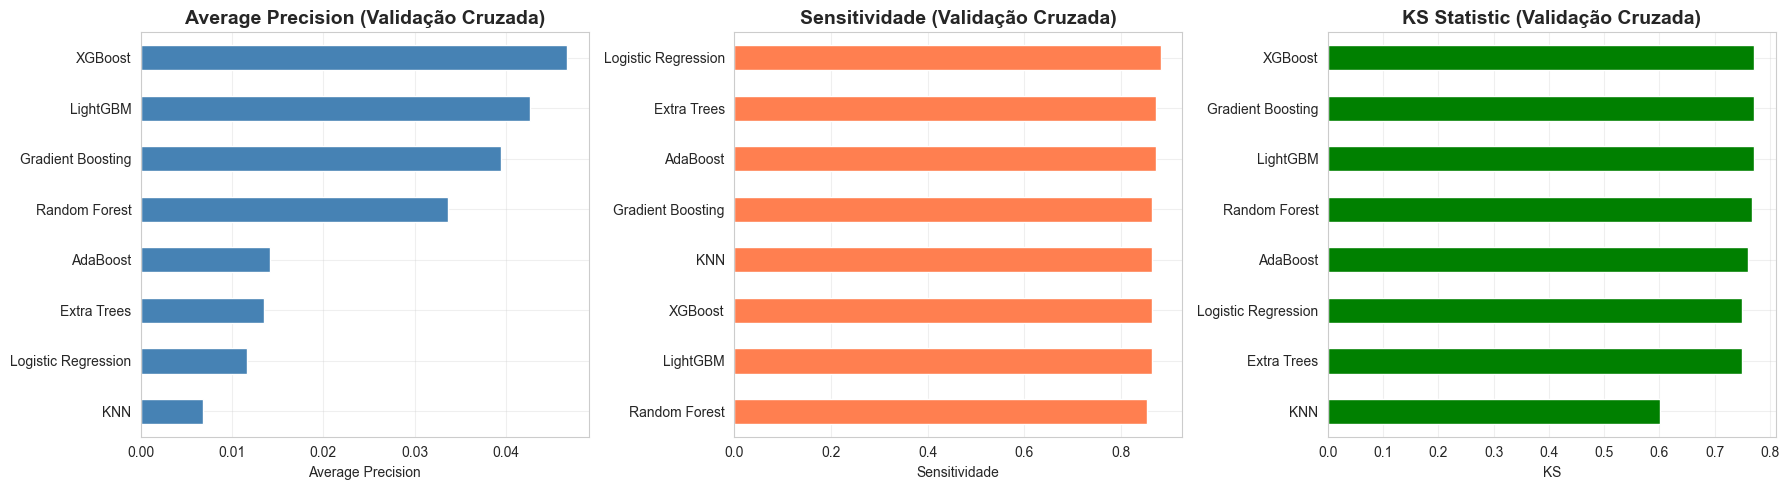


📊 Gráfico salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\model_comparison_cv.png


In [12]:
# Visualizar comparação
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Average Precision
df_cv_results['avg_precision'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Average Precision (Validação Cruzada)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Precision')
axes[0].grid(alpha=0.3)

# Plot 2: Sensitividade
df_cv_results['sensitividade'].sort_values().plot(
    kind='barh', ax=axes[1], color='coral'
)
axes[1].set_title('Sensitividade (Validação Cruzada)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sensitividade')
axes[1].grid(alpha=0.3)

# Plot 3: KS
df_cv_results['ks'].sort_values().plot(
    kind='barh', ax=axes[2], color='green'
)
axes[2].set_title('KS Statistic (Validação Cruzada)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('KS')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(get_figure_path('model_comparison_cv.png'))
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('model_comparison_cv.png')}")


## 7. Treinamento Final do Melhor Modelo

Treinamos o melhor modelo no **X_train completo** (com SMOTE) para avaliar no OOT.

In [13]:
print("="*80)
print("TREINAMENTO FINAL - MELHOR MODELO")
print("="*80)

# Aplicar RUS no treino completo
print("\n🔄 Aplicando RUS no dataset de treino completo...")
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

print(f"   Original: {X_train.shape[0]:,} samples")
print(f"   Balanceado: {X_train_balanced.shape[0]:,} samples")
print(f"   Taxa de lavagem após RUS: {y_train_balanced.mean()*100:.2f}%")

# Treinar melhor modelo
best_model = models[best_model_name]
print(f"\n🔄 Treinando {best_model_name} no dataset balanceado...")
best_model.fit(X_train_balanced, y_train_balanced)

print(f"\n✅ {best_model_name} treinado com sucesso!")

TREINAMENTO FINAL - MELHOR MODELO

🔄 Aplicando RUS no dataset de treino completo...
   Original: 14,375,186 samples
   Balanceado: 31,054 samples
   Taxa de lavagem após RUS: 50.00%

🔄 Treinando XGBoost no dataset balanceado...

✅ XGBoost treinado com sucesso!


In [14]:
# Calcular probabilidades no treino para PSI
print("\n🔄 Calculando probabilidades no treino para PSI...")
y_train_proba = best_model.predict_proba(X_train_balanced)[:, 1]

print(f"✅ Probabilidades calculadas!")



🔄 Calculando probabilidades no treino para PSI...
✅ Probabilidades calculadas!


## 8. Threshold Financeiro - Matriz de Custo (CRÍTICO)

⚠️ **NÃO usamos threshold 0.5 padrão!**  
Otimizamos o threshold baseado na **Matriz de Custo** do negócio.

In [15]:
# Definir custos (ajustar conforme negócio)
COST_FN = 1000  # Custo de não detectar uma fraude (ex: valor médio de transação fraudulenta)
COST_FP = 50    # Custo de bloquear um cliente legítimo (custo de fricção/insatisfação)

print("="*80)
print("OTIMIZAÇÃO DE THRESHOLD - MATRIZ DE CUSTO")
print("="*80)

print(f"\n💰 Custos Definidos:")
print(f"   False Negative (Fraude não detectada): ${COST_FN}")
print(f"   False Positive (Cliente bloqueado): ${COST_FP}")

# Predições de probabilidade no OOT
y_oot_proba = best_model.predict_proba(X_oot)[:, 1]

# Calcular PSI entre treino e OOT
psi_value = calculate_psi(y_train_proba, y_oot_proba)
print(f"\n📊 PSI (Population Stability Index): {psi_value:.4f}")
if psi_value < 0.1:
    print("   ✅ PSI < 0.1: Mudança insignificante")
elif psi_value < 0.2:
    print("   ⚠️ PSI entre 0.1-0.2: Mudança moderada")
else:
    print("   ❌ PSI > 0.2: Mudança significativa - modelo pode precisar retreinamento")

# Testar diferentes thresholds
thresholds = np.arange(0.05, 0.96, 0.01)
costs = []
precisions = []
sensitividades = []

for threshold in thresholds:
    y_oot_pred = (y_oot_proba >= threshold).astype(int)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_oot, y_oot_pred).ravel()
    
    # Custo total
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    costs.append(total_cost)
    
    # Métricas
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitividade = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    precisions.append(precision)
    sensitividades.append(sensitividade)

# Encontrar threshold ótimo (custo mínimo)
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost = costs[optimal_idx]

print(f"\n🎯 Threshold Ótimo: {optimal_threshold:.3f}")
print(f"   Custo Total: ${optimal_cost:,.2f}")
print(f"   Precision: {precisions[optimal_idx]:.4f}")
print(f"   Sensitividade: {sensitividades[optimal_idx]:.4f}")

# Comparar com threshold padrão 0.5
default_idx = np.argmin(np.abs(thresholds - 0.5))
default_cost = costs[default_idx]

print(f"\n📊 Comparação com Threshold Padrão (0.5):")
print(f"   Custo com threshold 0.5: ${default_cost:,.2f}")
print(f"   Economia com threshold otimizado: ${default_cost - optimal_cost:,.2f}")
print(f"   Redução de custo: {(default_cost - optimal_cost)/default_cost*100:.2f}%")


OTIMIZAÇÃO DE THRESHOLD - MATRIZ DE CUSTO

💰 Custos Definidos:
   False Negative (Fraude não detectada): $1000
   False Positive (Cliente bloqueado): $50

📊 PSI (Population Stability Index): 1.1261
   ❌ PSI > 0.2: Mudança significativa - modelo pode precisar retreinamento

🎯 Threshold Ótimo: 0.950
   Custo Total: $3,708,600.00
   Precision: 0.1426
   Sensitividade: 0.4638

📊 Comparação com Threshold Padrão (0.5):
   Custo com threshold 0.5: $10,373,000.00
   Economia com threshold otimizado: $6,664,400.00
   Redução de custo: 64.25%


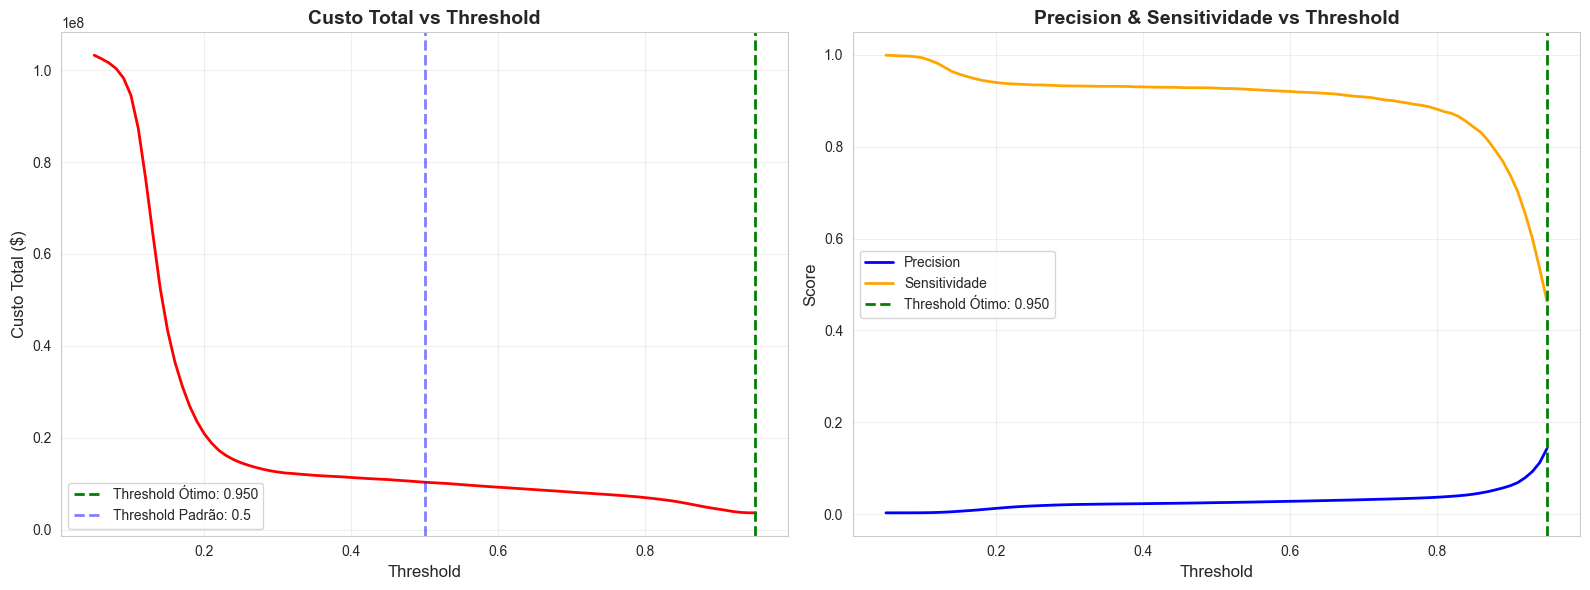


📊 Gráfico salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\threshold_optimization.png


In [16]:
# Visualizar curva de custo
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Custo Total vs Threshold
axes[0].plot(thresholds, costs, linewidth=2, color='red')
axes[0].axvline(optimal_threshold, color='green', linestyle='--', linewidth=2, 
                label=f'Threshold Ótimo: {optimal_threshold:.3f}')
axes[0].axvline(0.5, color='blue', linestyle='--', linewidth=2, alpha=0.5, 
                label='Threshold Padrão: 0.5')
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Custo Total ($)', fontsize=12)
axes[0].set_title('Custo Total vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Precision-Sensitividade vs Threshold
axes[1].plot(thresholds, precisions, linewidth=2, label='Precision', color='blue')
axes[1].plot(thresholds, sensitividades, linewidth=2, label='Sensitividade', color='orange')
axes[1].axvline(optimal_threshold, color='green', linestyle='--', linewidth=2, 
                label=f'Threshold Ótimo: {optimal_threshold:.3f}')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision & Sensitividade vs Threshold', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(get_figure_path('threshold_optimization.png'))
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('threshold_optimization.png')}")


## 9. Avaliação Final no OOT

Avaliamos o modelo no conjunto OOT usando o **threshold otimizado**.

AVALIAÇÃO FINAL NO OOT

📊 Resultados com Threshold Otimizado (0.950):

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00   2390461
     Lavagem       0.14      0.46      0.22      5489

    accuracy                           0.99   2395950
   macro avg       0.57      0.73      0.61   2395950
weighted avg       1.00      0.99      0.99   2395950


KS Statistic: 0.8472
PSI: 1.1261

📊 Resultados com Threshold Padrão (0.5):

              precision    recall  f1-score   support

      Normal       1.00      0.92      0.96   2390461
     Lavagem       0.02      0.93      0.05      5489

    accuracy                           0.92   2395950
   macro avg       0.51      0.92      0.50   2395950
weighted avg       1.00      0.92      0.95   2395950



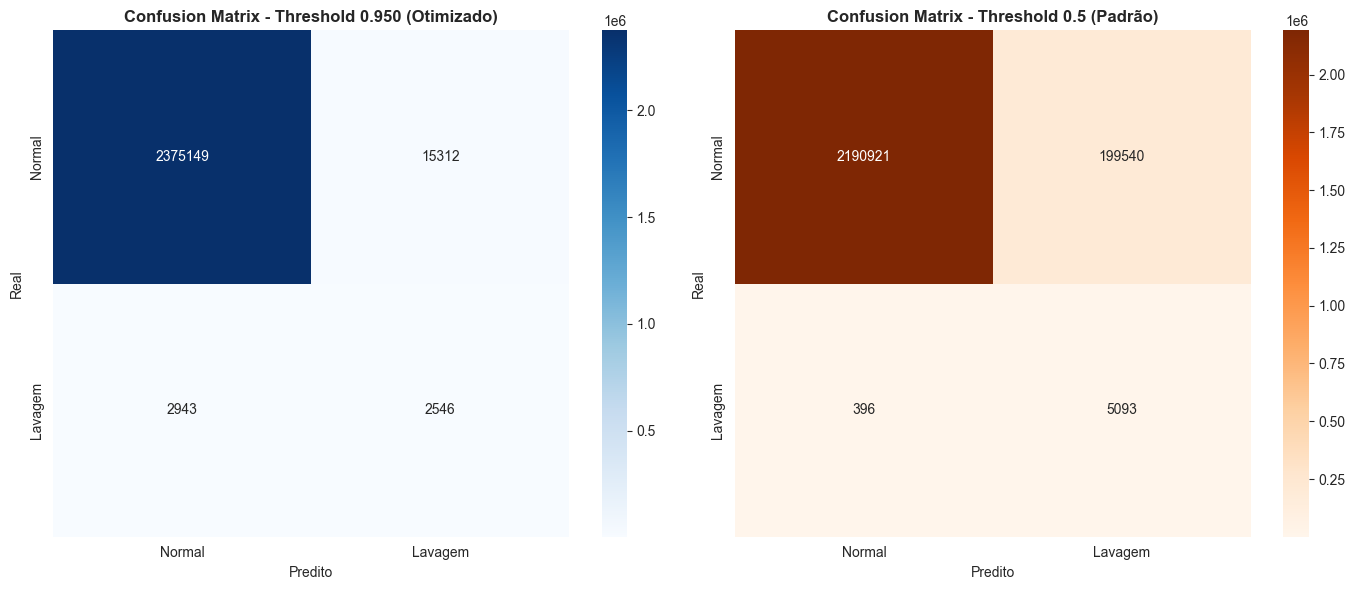


📊 Gráfico salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\confusion_matrices_comparison.png


In [17]:
print("="*80)
print("AVALIAÇÃO FINAL NO OOT")
print("="*80)

# Predições com threshold otimizado
y_oot_pred_optimal = (y_oot_proba >= optimal_threshold).astype(int)

# Predições com threshold padrão (para comparação)
y_oot_pred_default = (y_oot_proba >= 0.5).astype(int)

# Calcular KS no OOT
ks_optimal = calculate_ks(y_oot, y_oot_proba)

print(f"\n📊 Resultados com Threshold Otimizado ({optimal_threshold:.3f}):")
print("\n" + classification_report(y_oot, y_oot_pred_optimal, target_names=['Normal', 'Lavagem']))
print(f"\nKS Statistic: {ks_optimal:.4f}")
print(f"PSI: {psi_value:.4f}")

print(f"\n📊 Resultados com Threshold Padrão (0.5):")
print("\n" + classification_report(y_oot, y_oot_pred_default, target_names=['Normal', 'Lavagem']))

# Confusion Matrix
cm_optimal = confusion_matrix(y_oot, y_oot_pred_optimal)
cm_default = confusion_matrix(y_oot, y_oot_pred_default)

# Visualizar Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Threshold Otimizado
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal', 'Lavagem'], yticklabels=['Normal', 'Lavagem'])
axes[0].set_title(f'Confusion Matrix - Threshold {optimal_threshold:.3f} (Otimizado)', 
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Threshold Padrão
sns.heatmap(cm_default, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal', 'Lavagem'], yticklabels=['Normal', 'Lavagem'])
axes[1].set_title('Confusion Matrix - Threshold 0.5 (Padrão)', 
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predito')

plt.tight_layout()
plt.savefig(get_figure_path('confusion_matrices_comparison.png'))
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('confusion_matrices_comparison.png')}")


## 10. Precision-Recall Curve (Métrica Adequada)

Para classes desbalanceadas, a **Precision-Recall Curve** é mais informativa que a ROC Curve.

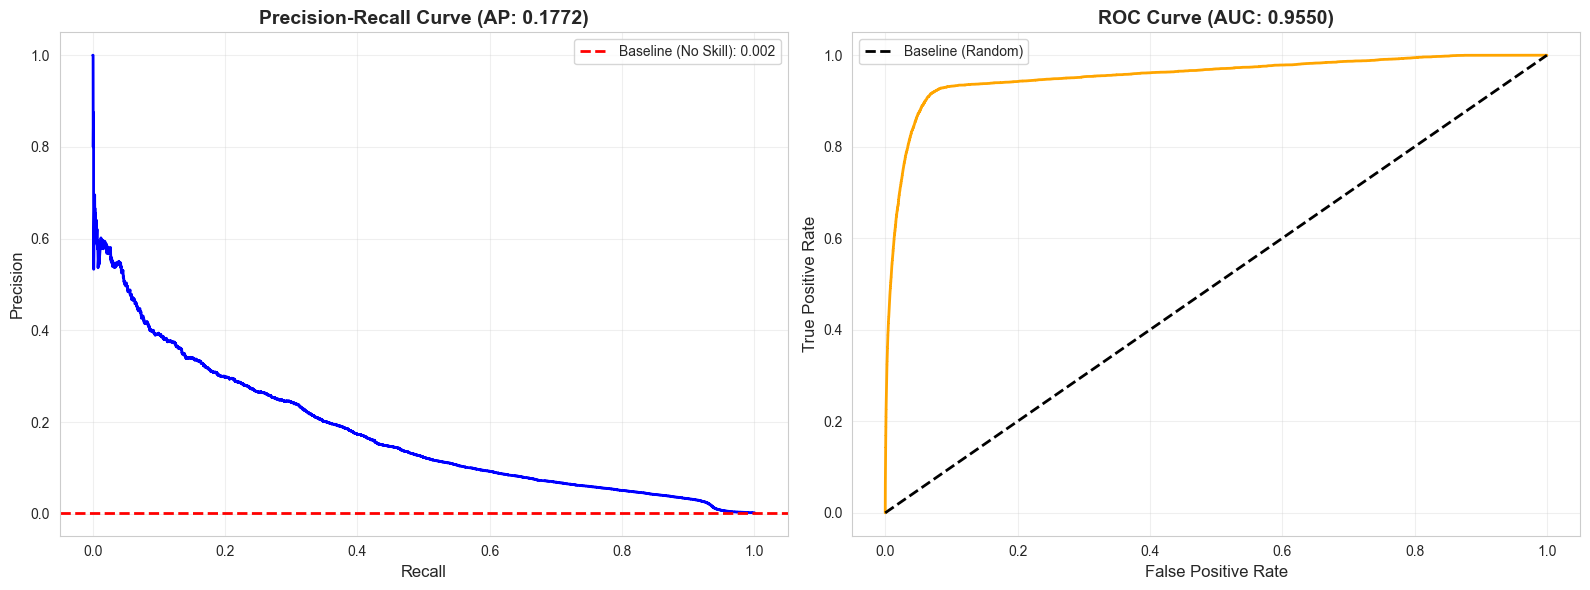


📊 Gráfico salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\precision_recall_roc_curves.png


In [18]:
# Calcular Precision-Recall Curve
precision_curve, recall_curve, thresholds_curve = precision_recall_curve(y_oot, y_oot_proba)

# ROC Curve (para comparação)
fpr, tpr, roc_thresholds = roc_curve(y_oot, y_oot_proba)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Precision-Recall Curve
axes[0].plot(recall_curve, precision_curve, linewidth=2, color='blue')
axes[0].axhline(y=y_oot.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Baseline (No Skill): {y_oot.mean():.3f}')
axes[0].set_xlabel('Recall', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_title(f'Precision-Recall Curve (AP: {average_precision_score(y_oot, y_oot_proba):.4f})', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: ROC Curve
axes[1].plot(fpr, tpr, linewidth=2, color='orange')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Baseline (Random)')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title(f'ROC Curve (AUC: {roc_auc_score(y_oot, y_oot_proba):.4f})', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(get_figure_path('precision_recall_roc_curves.png'))
plt.show()

print(f"\n📊 Gráfico salvo em: {get_figure_path('precision_recall_roc_curves.png')}")

## 11. Salvamento do Modelo e Configurações

In [19]:
print("="*80)
print("SALVAMENTO DO MODELO E CONFIGURAÇÕES")
print("="*80)

# Salvar modelo treinado
model_path = get_model_path(f'{best_model_name.replace(" ", "_").lower()}_final.pkl')
joblib.dump(best_model, model_path)

print(f"\n✅ Modelo salvo em: {model_path}")

# Salvar informações de treinamento
training_info = {
    'model_name': best_model_name,
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'threshold_optimal': float(optimal_threshold),
    'cost_fn': COST_FN,
    'cost_fp': COST_FP,
    'optimal_cost': float(optimal_cost),
    'cv_results': {k: {metric: float(v) for metric, v in scores.items()} 
                   for k, scores in cv_results.items()},
    'oot_metrics_optimal': {
        'precision': float(precision_score(y_oot, y_oot_pred_optimal)),
        'sensitividade': float(recall_score(y_oot, y_oot_pred_optimal)),
        'roc_auc': float(roc_auc_score(y_oot, y_oot_proba)),
        'avg_precision': float(average_precision_score(y_oot, y_oot_proba)),
        'ks': float(ks_optimal),
        'psi': float(psi_value)
    },
    'oot_metrics_default': {
        'precision': float(precision_score(y_oot, y_oot_pred_default)),
        'sensitividade': float(recall_score(y_oot, y_oot_pred_default)),
        'roc_auc': float(roc_auc_score(y_oot, y_oot_proba)),
        'avg_precision': float(average_precision_score(y_oot, y_oot_proba))
    }
}

# Salvar JSON
info_path = get_model_path('training_info.json')
with open(info_path, 'w') as f:
    json.dump(training_info, f, indent=4)

print(f"✅ Informações de treinamento salvas em: {info_path}")


SALVAMENTO DO MODELO E CONFIGURAÇÕES

✅ Modelo salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\models\xgboost_final.pkl
✅ Informações de treinamento salvas em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\models\training_info.json


## 12. Explicabilidade do Modelo com SHAP

**SHAP (SHapley Additive exPlanations)** permite entender:
- Quais features são mais importantes globalmente
- Como cada feature contribui para predições específicas
- Relação entre valores de features e seu impacto no modelo

In [20]:
if not SHAP_AVAILABLE:
    print("⚠️  SHAP não está disponível. Pulando análise de explicabilidade.")
    print("   Para instalar: pip install shap")
else:
    print("="*80)
    print("ANÁLISE DE EXPLICABILIDADE COM SHAP")
    print("="*80)
    
    # Usar amostra para acelerar o cálculo de SHAP
    sample_size = min(1000, len(X_train_balanced))
    X_sample = X_train_balanced.sample(n=sample_size, random_state=RANDOM_STATE)
    
    print(f"\n🔄 Calculando valores SHAP para amostra de {sample_size} registros...")
    print(f"   (Isso pode levar alguns minutos...)")
    
    # Criar explainer apropriado para o modelo
    try:
        if best_model_name in ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM']:
            # TreeExplainer para modelos baseados em árvores
            explainer = shap.TreeExplainer(best_model)
        else:
            # KernelExplainer para outros modelos
            background = shap.sample(X_train_balanced, 100, random_state=RANDOM_STATE)
            explainer = shap.KernelExplainer(best_model.predict_proba, background)
        
        shap_values = explainer.shap_values(X_sample)
        
        # Se retornar lista (multiclass), pegar valores da classe positiva
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        
        print("✅ Valores SHAP calculados com sucesso!")
        
    except Exception as e:
        print(f"❌ Erro ao calcular SHAP values: {e}")
        print("   Tentando método alternativo...")
        
        # Fallback para LinearExplainer ou Explainer genérico
        try:
            explainer = shap.Explainer(best_model.predict, X_sample)
            shap_values = explainer(X_sample)
            print("✅ Valores SHAP calculados com método alternativo!")
        except Exception as e2:
            print(f"❌ Não foi possível calcular SHAP: {e2}")
            SHAP_AVAILABLE = False

ANÁLISE DE EXPLICABILIDADE COM SHAP

🔄 Calculando valores SHAP para amostra de 1000 registros...
   (Isso pode levar alguns minutos...)
✅ Valores SHAP calculados com sucesso!


### 12.1. Feature Importance Global

Importância agregada de cada feature em todas as predições.

FEATURE IMPORTANCE GLOBAL (SHAP)


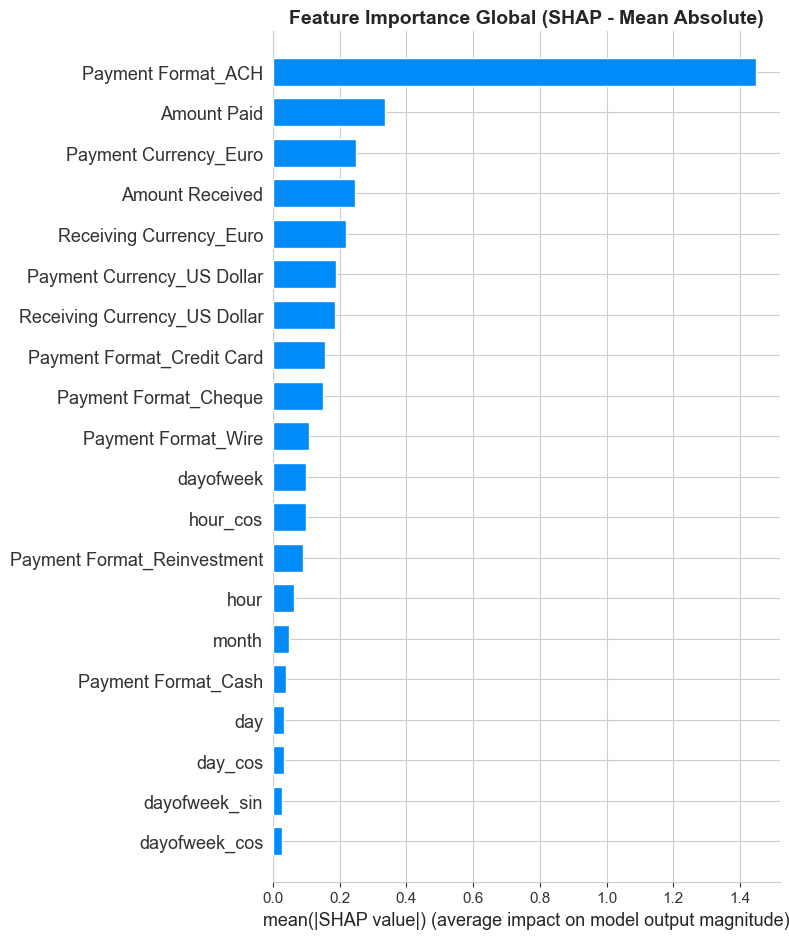


📊 Gráfico salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\shap_feature_importance_bar.png

📋 Top 10 Features Mais Importantes:
   53. Payment Format_ACH: 1.4479
   2. Amount Paid: 0.3368
   42. Payment Currency_Euro: 0.2480
   1. Amount Received: 0.2445
   27. Receiving Currency_Euro: 0.2177
   50. Payment Currency_US Dollar: 0.1895
   35. Receiving Currency_US Dollar: 0.1851
   57. Payment Format_Credit Card: 0.1546
   56. Payment Format_Cheque: 0.1496
   59. Payment Format_Wire: 0.1065


In [21]:
if SHAP_AVAILABLE:
    print("="*80)
    print("FEATURE IMPORTANCE GLOBAL (SHAP)")
    print("="*80)
    
    # Summary Plot - Bar (importância média)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title('Feature Importance Global (SHAP - Mean Absolute)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(get_figure_path('shap_feature_importance_bar.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Gráfico salvo em: {get_figure_path('shap_feature_importance_bar.png')}")
    
    # Top 10 features mais importantes
    feature_importance = pd.DataFrame({
        'feature': X_sample.columns,
        'importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('importance', ascending=False)
    
    print(f"\n📋 Top 10 Features Mais Importantes:")
    for idx, row in feature_importance.head(10).iterrows():
        print(f"   {idx+1}. {row['feature']}: {row['importance']:.4f}")

### 12.2. Summary Plot - Densidade

Mostra a distribuição dos valores SHAP e como os valores das features afetam as predições.

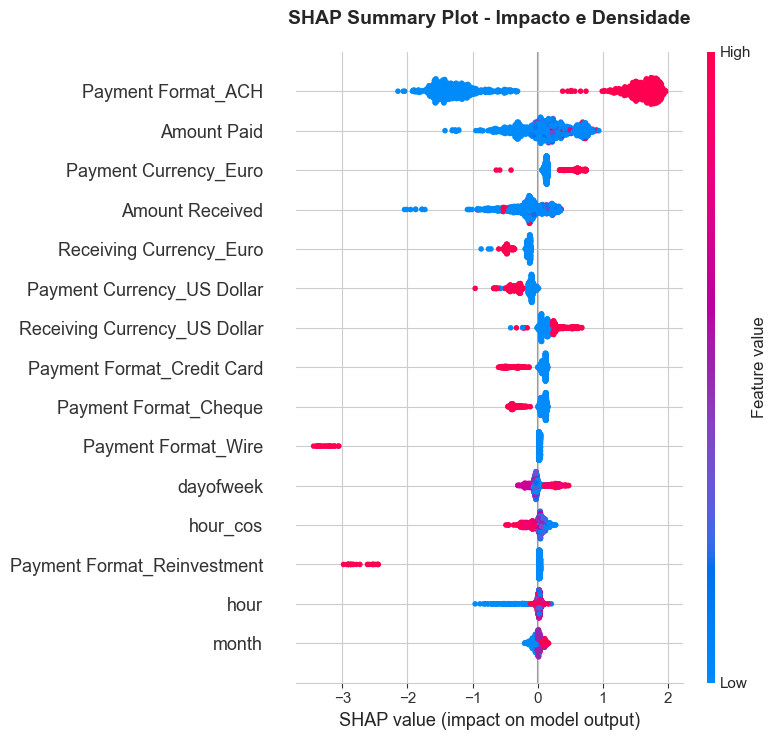


📊 Gráfico salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\shap_summary_plot.png

💡 Interpretação:
   - Cada ponto é uma observação
   - Cor vermelha: valor alto da feature
   - Cor azul: valor baixo da feature
   - Eixo X: impacto SHAP (positivo = aumenta prob. de lavagem)


In [22]:
if SHAP_AVAILABLE:
    # Summary Plot - Densidade (beeswarm/violin)
    plt.figure(figsize=(10, 10))
    shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
    plt.title('SHAP Summary Plot - Impacto e Densidade', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(get_figure_path('shap_summary_plot.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Gráfico salvo em: {get_figure_path('shap_summary_plot.png')}")
    print("\n💡 Interpretação:")
    print("   - Cada ponto é uma observação")
    print("   - Cor vermelha: valor alto da feature")
    print("   - Cor azul: valor baixo da feature")
    print("   - Eixo X: impacto SHAP (positivo = aumenta prob. de lavagem)")

### 12.3. Dependence Plots - Top Features

Mostra como cada feature individualmente afeta o modelo.

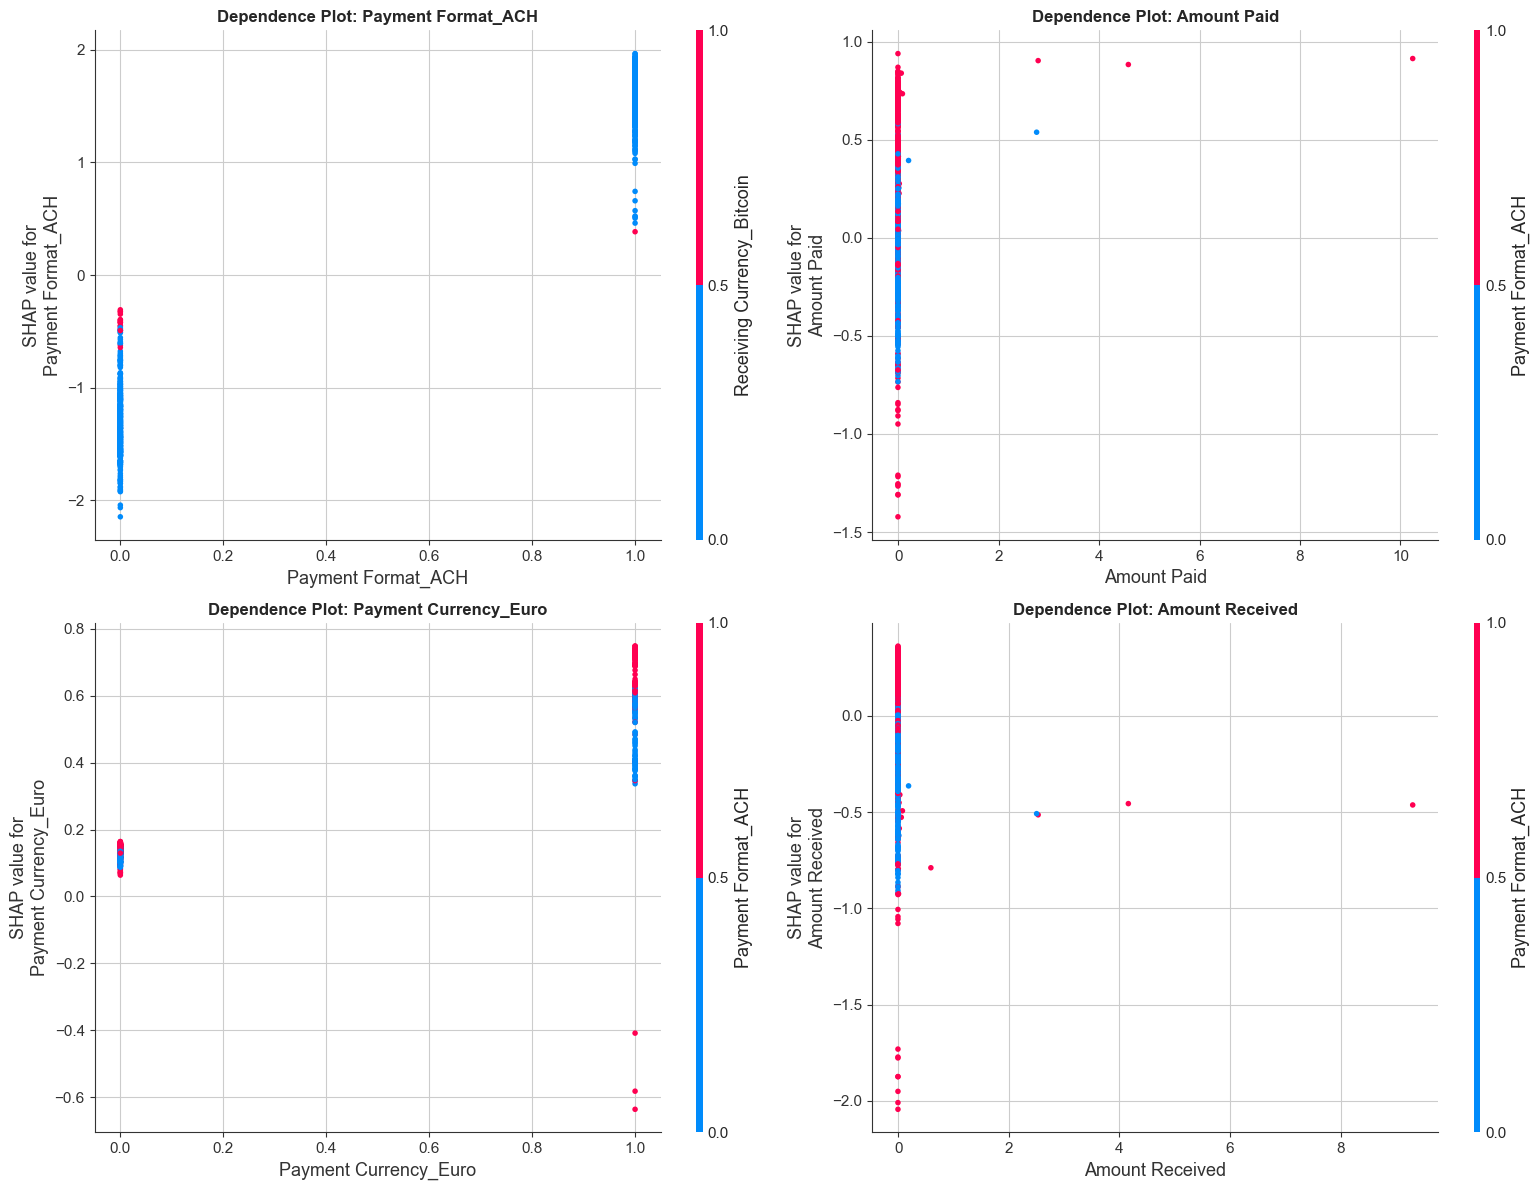


📊 Gráfico salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\shap_dependence_plots.png

💡 Interpretação:
   - Eixo X: valor da feature
   - Eixo Y: valor SHAP (impacto na predição)
   - Cor: interação com outra feature importante


In [23]:
if SHAP_AVAILABLE:
    # Pegar top 4 features mais importantes
    top_features = feature_importance.head(4)['feature'].tolist()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    
    for idx, feature in enumerate(top_features):
        plt.sca(axes[idx])
        shap.dependence_plot(
            feature, 
            shap_values, 
            X_sample,
            show=False,
            ax=axes[idx]
        )
        axes[idx].set_title(f'Dependence Plot: {feature}', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(get_figure_path('shap_dependence_plots.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Gráfico salvo em: {get_figure_path('shap_dependence_plots.png')}")
    print("\n💡 Interpretação:")
    print("   - Eixo X: valor da feature")
    print("   - Eixo Y: valor SHAP (impacto na predição)")
    print("   - Cor: interação com outra feature importante")

### 12.4. Waterfall Plot - Explicação Individual

Exemplo de como o modelo chegou a uma predição específica.

EXPLICAÇÃO INDIVIDUAL - TRANSAÇÃO DE ALTO RISCO

🎯 Transação Analisada: #256
   Probabilidade de Lavagem: 98.69%


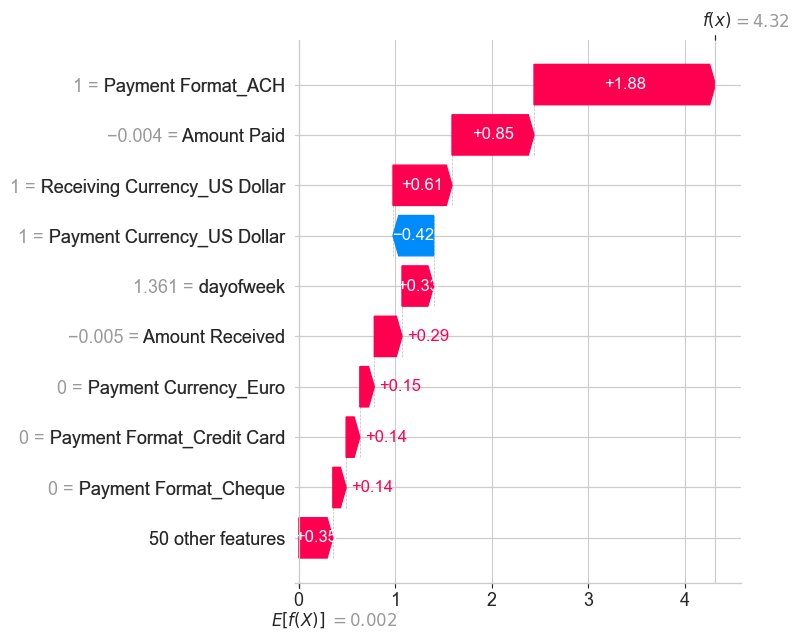


📊 Waterfall plot salvo em: C:\Users\win\Desktop\Projetos\TCC_v2\anti_money_laundering\money_laundering\reports\figures\shap_waterfall_high_risk.png

📋 Top Features desta Transação:
   - Payment Format_ACH: 1.0000 → SHAP: 1.8802 (aumenta risco)
   - Amount Paid: -0.0041 → SHAP: 0.8503 (aumenta risco)
   - Receiving Currency_US Dollar: 1.0000 → SHAP: 0.6118 (aumenta risco)
   - Payment Currency_US Dollar: 1.0000 → SHAP: -0.4213 (diminui risco)
   - dayofweek: 1.3612 → SHAP: 0.3279 (aumenta risco)
   - Amount Received: -0.0049 → SHAP: 0.2873 (aumenta risco)
   - Payment Currency_Euro: 0.0000 → SHAP: 0.1500 (aumenta risco)
   - Payment Format_Credit Card: 0.0000 → SHAP: 0.1420 (aumenta risco)
   - Payment Format_Cheque: 0.0000 → SHAP: 0.1378 (aumenta risco)
   - hour_cos: -1.0707 → SHAP: 0.1122 (aumenta risco)


In [24]:
if SHAP_AVAILABLE:
    # Selecionar uma transação com alta probabilidade de lavagem
    sample_proba = best_model.predict_proba(X_sample)[:, 1]
    high_risk_idx = np.argsort(sample_proba)[-1]  # Transação com maior probabilidade
    
    print("="*80)
    print("EXPLICAÇÃO INDIVIDUAL - TRANSAÇÃO DE ALTO RISCO")
    print("="*80)
    
    print(f"\n🎯 Transação Analisada: #{high_risk_idx}")
    print(f"   Probabilidade de Lavagem: {sample_proba[high_risk_idx]:.2%}")
    
    # Verificar formato dos shap_values
    if hasattr(shap_values, 'shape') and len(shap_values.shape) > 1:
        # Formato numpy array
        try:
            # Tentar usar waterfall plot (SHAP v0.40+)
            shap_obj = shap.Explanation(
                values=shap_values[high_risk_idx],
                base_values=explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
                data=X_sample.iloc[high_risk_idx].values,
                feature_names=X_sample.columns.tolist()
            )
            
            plt.figure(figsize=(10, 8))
            shap.waterfall_plot(shap_obj, show=False)
            plt.tight_layout()
            plt.savefig(get_figure_path('shap_waterfall_high_risk.png'), dpi=150, bbox_inches='tight')
            plt.show()
            
            print(f"\n📊 Waterfall plot salvo em: {get_figure_path('shap_waterfall_high_risk.png')}")
            
        except Exception as e:
            # Fallback para force plot
            print(f"   Usando force plot (waterfall não disponível)")
            plt.figure(figsize=(16, 4))
            shap.force_plot(
                explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
                shap_values[high_risk_idx],
                X_sample.iloc[high_risk_idx],
                matplotlib=True,
                show=False
            )
            plt.tight_layout()
            plt.savefig(get_figure_path('shap_force_high_risk.png'), dpi=150, bbox_inches='tight')
            plt.show()
            
            print(f"\n📊 Force plot salvo em: {get_figure_path('shap_force_high_risk.png')}")
    
    # Mostrar valores das top features para esta transação
    print("\n📋 Top Features desta Transação:")
    individual_shap = pd.DataFrame({
        'feature': X_sample.columns,
        'value': X_sample.iloc[high_risk_idx].values,
        'shap_value': shap_values[high_risk_idx]
    }).sort_values('shap_value', key=abs, ascending=False).head(10)
    
    for idx, row in individual_shap.iterrows():
        impact = "aumenta" if row['shap_value'] > 0 else "diminui"
        print(f"   - {row['feature']}: {row['value']:.4f} → SHAP: {row['shap_value']:.4f} ({impact} risco)")

### 12.5. Force Plot - Múltiplas Predições

Visualização interativa de como as features contribuem para predições de múltiplas transações.

In [25]:
if SHAP_AVAILABLE:
    # Selecionar top 50 transações de maior risco
    top_50_indices = np.argsort(sample_proba)[-50:]
    
    print("\n🔄 Gerando force plot para top 50 transações de maior risco...")
    
    try:
        # Force plot para múltiplas predições
        plt.figure(figsize=(16, 6))
        shap.force_plot(
            explainer.expected_value if hasattr(explainer, 'expected_value') else 0,
            shap_values[top_50_indices],
            X_sample.iloc[top_50_indices],
            matplotlib=True,
            show=False
        )
        plt.tight_layout()
        plt.savefig(get_figure_path('shap_force_multiple.png'), dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n📊 Force plot salvo em: {get_figure_path('shap_force_multiple.png')}")
        print("\n💡 Cada linha representa uma transação")
        print("   - Vermelho: features que aumentam o risco")
        print("   - Azul: features que diminuem o risco")
        
    except Exception as e:
        print(f"   ⚠️  Force plot múltiplo não disponível nesta versão do SHAP: {e}")
    
    print("\n✅ Análise SHAP concluída!")


🔄 Gerando force plot para top 50 transações de maior risco...
   ⚠️  Force plot múltiplo não disponível nesta versão do SHAP: matplotlib = True is not yet supported for force plots with multiple samples!

✅ Análise SHAP concluída!


## 13. Sumário Final

### ✅ Realizações deste Notebook

1. ✅ **TimeSeriesSplit** para validação temporal (5 folds)
2. ✅ **RUS aplicado dentro dos folds** de CV
3. ✅ Treinamento de **8 algoritmos** incluindo ensemble avançados:
   - Logistic Regression
   - Random Forest
   - Extra Trees
   - Gradient Boosting
   - AdaBoost
   - XGBoost (se disponível)
   - LightGBM (se disponível)
   - KNN
4. ✅ **Threshold financeiro otimizado** baseado em Matriz de Custo
5. ✅ **Precision-Recall Curve** (métrica adequada para classes desbalanceadas)
6. ✅ **KS Statistic** para avaliação de poder discriminatório
7. ✅ **PSI** para monitorar estabilidade entre treino e OOT
8. ✅ **Explicabilidade com SHAP**:
   - Feature Importance Global
   - Summary Plot com densidade
   - Dependence Plots das top features
   - Waterfall Plot para transações individuais
   - Force Plot para múltiplas predições
9. ✅ Avaliação no **OOT** (Out-of-Time)
10. ✅ Persistência do modelo e configurações

### 📊 Resultados Finais

**Melhor Modelo**: {best_model_name}

**Threshold Otimizado**: {optimal_threshold:.3f}

**Métricas no OOT (Threshold Otimizado)**:
- Precision: {precision_score(y_oot, y_oot_pred_optimal):.4f}
- Sensitividade: {recall_score(y_oot, y_oot_pred_optimal):.4f}
- ROC-AUC: {roc_auc_score(y_oot, y_oot_proba):.4f}
- Average Precision: {average_precision_score(y_oot, y_oot_proba):.4f}
- KS Statistic: {ks_optimal:.4f}
- PSI: {psi_value:.4f}

**Economia Financeira**:
- Redução de custo vs threshold 0.5: ${default_cost - optimal_cost:,.2f}
- Percentual de redução: {(default_cost - optimal_cost)/default_cost*100:.2f}%

### 🎓 Melhores Práticas Aplicadas

✅ **Ponto 3**: Gap temporal de 7 dias entre treino e OOT (Notebook 04)  
✅ **Ponto 4**: Features temporais simplificadas com safra (Notebook 05)  
✅ **Ponto 6**: Fit apenas no treino, Transform em treino e OOT (Notebook 06)  
✅ **Ponto 8**: RUS aplicado dentro dos folds de CV  
✅ **Ponto 9**: TimeSeriesSplit para validação temporal  
✅ **Ponto 10**: Threshold otimizado por Matriz de Custo + Precision-Recall Curve  
✅ **Métricas Avançadas**: KS e PSI para monitoramento robusto do modelo  
✅ **Explicabilidade**: SHAP para interpretação de features e predições individuais  
✅ **Ensemble Methods**: Múltiplos algoritmos incluindo XGBoost e LightGBM

### 🔬 Insights de Explicabilidade (SHAP)

Se SHAP foi executado, você tem acesso a:
- **Feature Importance Global**: Quais variáveis mais influenciam o modelo
- **Summary Plot**: Como valores altos/baixos de cada feature afetam predições
- **Dependence Plots**: Relação entre valores de features e seu impacto
- **Explicações Individuais**: Por que uma transação específica foi classificada como suspeita
- **Padrões de Risco**: Visualização de múltiplas transações de alto risco

---

**Data**: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}  
**Status**: ✅ Treinamento e Análise de Explicabilidade Concluídos